In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
import statsmodels.api as sm
from scipy.signal import lfilter

### Why ADF alone isn't enough

In [40]:
rng = np.random.default_rng(42)
T = 2000

In [41]:
# x -> random walk
x = 100 + np.cumsum(rng.normal(0, 1, T))

# Stationart AR(1) noise
phi = 0.9
e = np.zeros(T)
eps = rng.normal(0, 1, T)
for t in range(1, T):
    e[t] = phi * e[t-1] + eps[t]

y = 10 + 2 * x + e

In [42]:
def adf_report(name, s, lags=1):
    stat, p, _, _, crit  = adfuller(s, maxlag=lags, regression="c", autolag=None)
    verdict = "STATIONARY" if stat < crit["5%"] else "non-stationary"
    print(f"{name:<16} stat={stat:8.3f}  p={p:.4f}  5% crit={crit['5%']:.3f}  -> {verdict}")


In [43]:
adf_report("x", x)
adf_report("y", y)

x                stat=   1.219  p=0.9961  5% crit=-2.863  -> non-stationary
y                stat=   0.993  p=0.9942  5% crit=-2.863  -> non-stationary


In [44]:
for h in np.arange(0, 3.5, 0.5):
    adf_report(f"y - {h}*x", y - h * x)

y - 0.0*x        stat=   0.993  p=0.9942  5% crit=-2.863  -> non-stationary
y - 0.5*x        stat=   0.822  p=0.9920  5% crit=-2.863  -> non-stationary
y - 1.0*x        stat=   0.427  p=0.9825  5% crit=-2.863  -> non-stationary
y - 1.5*x        stat=  -0.722  p=0.8409  5% crit=-2.863  -> non-stationary
y - 2.0*x        stat=  -9.927  p=0.0000  5% crit=-2.863  -> STATIONARY
y - 2.5*x        stat=  -1.137  p=0.7002  5% crit=-2.863  -> non-stationary
y - 3.0*x        stat=   0.157  p=0.9697  5% crit=-2.863  -> non-stationary


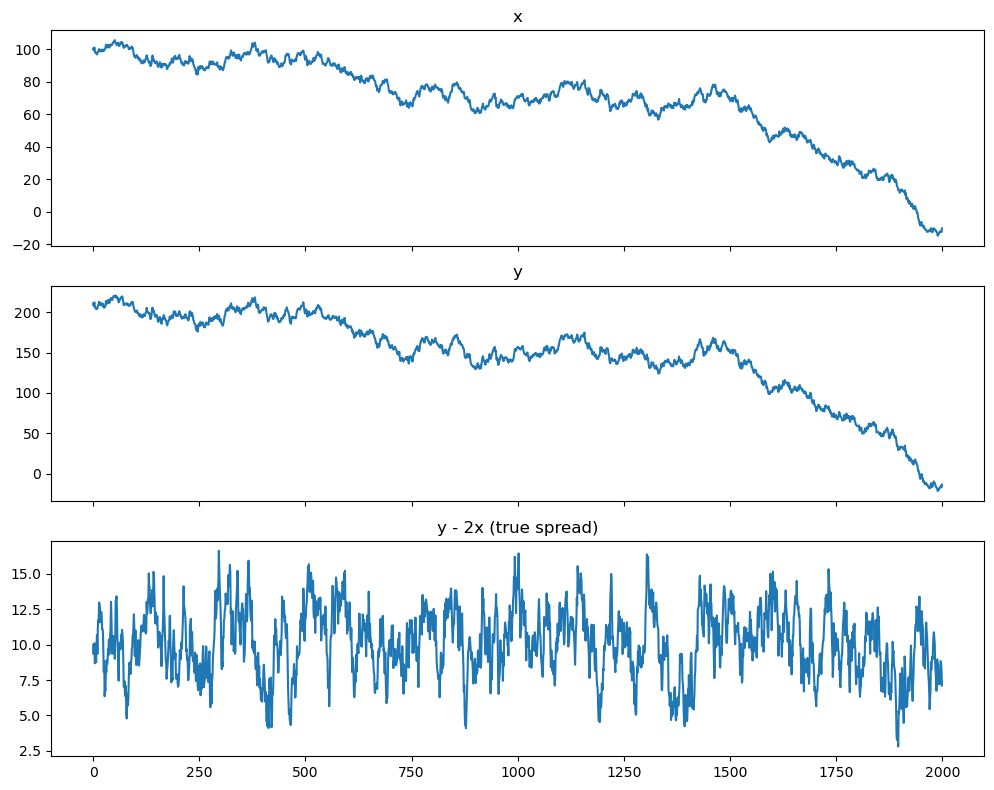

In [45]:
fig, ax = plt.subplots(3,1, figsize=(10, 8), sharex=True)
ax[0].plot(x); ax[0].set_title("x")
ax[1].plot(y); ax[1].set_title("y")
ax[2].plot(y - 2*x); ax[2].set_title("y - 2x (true spread)")
plt.tight_layout()
plt.show()

### Engle-Granger (CADF)

### **Procedure**
- Regress y on x with a constant: y = c + β·x + u. β is the hedge ratio.
- Run ADF on the residuals u (the spread).
- Compare against MacKinnon cointegration critical values, not the standard ADF ones.

In [49]:
def simulate(T, phi, rng):
    x = 100 + np.cumsum(rng.normal(0, 1, T))
    e = lfilter([1], [1, -phi], rng.normal(0, 1, T))
    y = 10 + 2 * x + e
    return x, y

def eg_manual(y, x, maxlag=1):
    res = sm.OLS(y, sm.add_constant(x)).fit()
    beta, resid = res.params[1], res.resid
    stat = adfuller(resid, maxlag=maxlag, regression="n", autolag=None)[0]
    return beta, stat

In [104]:
rng = np.random.default_rng(1)
x, y = simulate(1000, 0.9, rng)

In [105]:
beta , stat = eg_manual(y, x)
c_stat, c_p, c_crit = coint(y, x, trend="c", maxlag=1, autolag=None)

In [106]:
print("--- Part A: manual vs coint (should match) ---")
print(f"manual: beta={beta:.4f}  ADF stat={stat:.4f}")
print(f"coint : stat={c_stat:.4f}  p={c_p:.4f}  crit(1/5/10%)={np.round(c_crit, 3)}")
print(f"standard ADF 5% crit is about -2.86; EG 5% crit is {c_crit[1]:.2f}")

--- Part A: manual vs coint (should match) ---
manual: beta=1.9669  ADF stat=-7.8859
coint : stat=-7.8859  p=0.0000  crit(1/5/10%)=[-3.907 -3.342 -3.049]
standard ADF 5% crit is about -2.86; EG 5% crit is -3.34


In [55]:
b_yx = sm.OLS(y, sm.add_constant(x)).fit().params[1]
b_xy = sm.OLS(x, sm.add_constant(y)).fit().params[1]

In [56]:
print("\n--- Part B: order dependence ---")
print(f"y on x: beta={b_yx:.4f}")
print(f"x on y: beta={b_xy:.4f}  -> implied y-on-x ratio = {1/b_xy:.4f}")
print(f"beta_yx * beta_xy = R^2 = {b_yx*b_xy:.4f}")
print(f"coint(y,x) stat={coint(y,x,maxlag=1,autolag=None)[0]:.3f}   "
      f"coint(x,y) stat={coint(x,y,maxlag=1,autolag=None)[0]:.3f}")


--- Part B: order dependence ---
y on x: beta=1.9669
x on y: beta=0.5063  -> implied y-on-x ratio = 1.9750
beta_yx * beta_xy = R^2 = 0.9959
coint(y,x) stat=-7.886   coint(x,y) stat=-7.853


### Part C: why the critical values matter
x and y are INDEPENDENT random walks: no cointegration exists. \
Every rejection is a false positive; a correct test rejects about 5%.

In [84]:
n_sims , T = 1000, 500
rng = np.random.default_rng(7)
naive = correct = 0
for _ in range (n_sims):
    a = np.cumsum(rng.normal(size=T))
    b = np.cumsum(rng.normal(size=T))

    _, s = eg_manual(a, b)
    naive += s < -2.86
    p = coint(a, b, maxlag=1, autolag=None)[1]
    correct += p < 0.05

In [85]:
print("\n--- Part C: false positive rate on independent random walks ---")
print(f"naive ADF on residuals (-2.86): {naive/n_sims:.1%}")
print(f"coint (MacKinnon):              {correct/n_sims:.1%}")


--- Part C: false positive rate on independent random walks ---
naive ADF on residuals (-2.86): 14.6%
coint (MacKinnon):              5.3%
